# IMEN266 · Ch.7 · Class Problems 9 (part 2) — Renewal reward, age and remaining time, inspection paradox, regenerative processes

**How this notebook works** — every problem follows the same 5 steps:

> **Problem → Model → Analytic → Simulate & Visualize → Experiment**

The analytic answer and the simulation must agree. *That agreement — not the
instructor, not an AI — is your ground truth.*

**In-class version only:** cells marked `# TODO` are for you to complete during
class. A `check(...)` cell right after tells you immediately whether your answer
matches the reference value.

▶ Open in Colab: `https://colab.research.google.com/github/youngmko/imen266-2026/blob/main/ch07/notebooks/CP10_renewal_reward.ipynb`

**The facts of this notebook** *(slides pp. 30–54/54; Companion Proofs 5–8)*

- **Renewal reward theorem:** with iid pairs $(X_n, R_n)$ (the reward of a cycle
  may depend on its own length), $R(t)/t\to E[R]/E[X]$ a.s. and in expectation —
  the long-run rate is a **ratio of means**, never $E[R/X]$.
- **Age $A(t)$, remaining time $Y(t)$, spread $C(t)=A(t)+Y(t)$:** the time averages
  of $A$ and $Y$ are $E[X^2]/(2E[X])$; the interval covering a random time is
  **length-biased** (density $xf(x)/E[X]$, mean $E[X^2]/E[X]\ge E[X]$) — the
  **inspection paradox**.
- **Regenerative processes:** fraction of time in state $j$ = $E[$time in $j$ per
  cycle$]/E[$cycle$]$; **alternating renewal:** on-fraction $E[Z]/(E[Z]+E[Y])$ —
  only the *means* of the on/off times matter (insensitivity).

In code (course package `imen266.renewal`): `renewal_reward(sampler, reward_fn, T, rng)`,
`age_residual`, `age_residual_samples`, `equilibrium_cdf`, `length_biased_pdf`,
`inspection_paradox_demo`, `alternating_renewal(on, off, T, rng)`, `semi_markov`;
from `imen266.ctmc`: `poisson_process`, `machine_repair`.

In [1]:
# --- IMEN266 setup (Ch.7): course package + helpers ---------------------------
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

try:                                   # local clone / PLMS zip: package is on the path
    from imen266.renewal import simulate_renewal
except ImportError:                    # Colab: fetch the course package from GitHub (~5 s)
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "git+https://github.com/youngmko/imen266-2026.git"], check=True)
    from imen266.renewal import simulate_renewal
from imen266.renewal import (hyperexp, sampler_from, samplers_same_mean, count,
                             renewal_function, renewal_function_series, renewal_function_mc,
                             m_uniform01, m_hyperexp, m_erlang2, rate_convergence_plot,
                             renewal_reward, age_residual, age_residual_samples,
                             equilibrium_cdf, length_biased_pdf, inspection_paradox_demo,
                             alternating_renewal, semi_markov)
from imen266.ctmc import poisson_process, CTMC, machine_repair
from imen266.check import check        # [TODO]/[OK]/[X] self-check (unfinished TODOs never crash)

rng = np.random.default_rng(2026)
plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11,
                     "legend.frameon": False})

def plot_counting(epochs, T, ax=None, **kw):
    """Step plot of N(t) on [0, T] from the renewal epochs S_1 < S_2 < ... ."""
    ax = ax or plt.gca()
    S = np.asarray(epochs); S = S[S <= T]
    ax.step(np.concatenate([[0.0], S, [T]]), np.concatenate([[0], np.arange(1, len(S) + 1), [len(S)]]), where="post", **kw)
    ax.set_xlabel("t"); ax.set_ylabel("N(t)")
    return ax

def plot_sawtooth(epochs, T, ax=None):
    """Age A(t) (rising) and remaining time Y(t) (falling) on [0, T]; epochs must extend beyond T."""
    ax = ax or plt.gca()
    ts = np.linspace(0, T, 2000)
    A, Y, _ = age_residual(epochs, ts)
    ax.plot(ts, A, lw=1.2, label="age A(t)"); ax.plot(ts, Y, lw=1.2, label="remaining Y(t)")
    ax.set_xlabel("t"); ax.legend(fontsize=8)
    return ax

try:
    from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider
    HAS_W = True
except Exception:
    HAS_W = False

def show(fn, **sliders):
    """interact() if widgets are available; otherwise draw once with defaults."""
    if HAS_W:
        interact(fn, **sliders)
    else:
        fn(**{k: getattr(v, "value", v) for k, v in sliders.items()})

print("Setup OK.  imen266.renewal imported.  Widgets available:", HAS_W)

Setup OK.  imen266.renewal imported.  Widgets available: True


---
## Warm-up · A ratio of means, not a mean of ratios *(slides pp. 30–31/54)*

Cycles $X\sim$ uniform$(0.5,1.5)$ (mean 1) with reward $R=X^2$ per cycle. The
long-run reward rate is $E[R]/E[X]=E[X^2]/E[X]=\tfrac{1}{12}+1$, while the
tempting "average of $R/X$" is $E[X]=1$. Simulate $R(t)/t$ and watch which one it
converges to.

In [3]:
U = stats.uniform(0.5, 1.0)                           # cycle length X ~ uniform(0.5, 1.5): mean 1, var 1/12
EX, EX2 = 1.0, 1/12 + 1.0                               # E[X], E[X^2] = Var + mean^2
rate_theory = EX2 / EX                                  # E[R]/E[X] with R = X^2
res = renewal_reward(sampler_from(U), lambda X, r: X**2, T=50_000, rng=rng)
print(f"E[R]/E[X] = {rate_theory:.4f}    simulated R(T)/T = {res['rate']:.4f}    mean of R/X (wrong) = {res['mean_of_ratios']:.4f}")

E[R]/E[X] = 1.0833    simulated R(T)/T = 1.0815    mean of R/X (wrong) = 0.9981


In [4]:
check("long-run reward rate E[R]/E[X]", rate_theory, 1/12 + 1, tol=1e-6)

[OK ] long-run reward rate E[R]/E[X]: got 1.08333   (reference 1.08333)


True

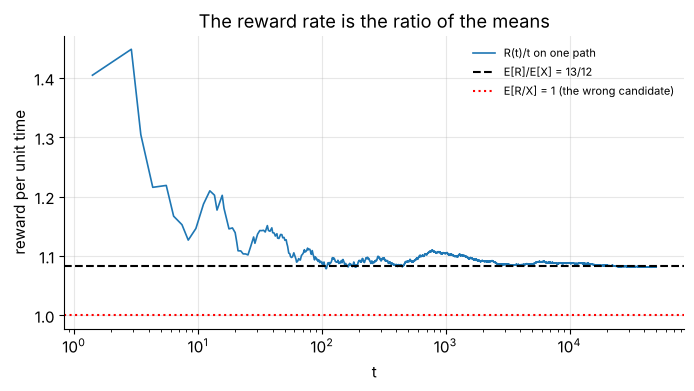

In [5]:
# --- Visualize: R(t)/t along one path --------------------------------------------------------------
X, R, S = res["X"], res["R"], res["S"]
cumR = np.cumsum(R)
plt.figure(figsize=(8, 3.8))
plt.plot(S, cumR / S, lw=1.2, label="R(t)/t on one path")
plt.axhline(1/12 + 1, color="k", ls="--", label="E[R]/E[X] = 13/12")
plt.axhline(1.0, color="r", ls=":", label="E[R/X] = 1 (the wrong candidate)")
plt.xscale("log"); plt.xlabel("t"); plt.ylabel("reward per unit time"); plt.legend(fontsize=8)
plt.title("The reward rate is the ratio of the means"); plt.show()

**Think about it** — (i) Rewrite $R(t)/t$ as $\big(\sum_{n\le N(t)}R_n/N(t)\big)\cdot\big(N(t)/t\big)$
and name the two theorems that give the limit. (ii) When would $E[R/X]$ and
$E[R]/E[X]$ coincide? (Two different sufficient conditions.)

---
## Problem 3 — The door with a lockout: cost per unit time *(slide p. 32/54)*

> Customers arrive to a single-server queueing system according to $PP(\lambda)$.
> The arriving customer must pass through a door to reach the server. Each time a
> customer passes through, the door is locked for the next $t$ units of time. If
> the door is locked when a customer arrives, the customer is lost incurring a
> cost $c$. After passing through the door, if the server is free, the customer
> gets service. If not, the customer is lost incurring a cost $K$. If the service
> times follow $\exp(\mu)$, what is the average cost per unit time?

### Model
A cycle starts each time a customer passes: $X=t+\exp(\lambda)$, $E[X]=t+1/\lambda$.
Cost per cycle $R=C_1+C_2$: $E[C_1]=\lambda t c$ (arrivals during the lock) and
$E[C_2]=K\,P(Y>t+Z)=K e^{-\mu t}\lambda/(\lambda+\mu)$ (the next passer finds the
server busy; $Y\sim\exp(\mu)$ remaining service, $Z\sim\exp(\lambda)$ wait after the
lock). Cost rate $=E[R]/E[X]$ (slides pp. 33–34/54).
Numbers: $\lambda=1$/min, $t=1$ min, $\mu=0.5$/min, $c=1$, $K=5$.

In [6]:
lam, t_lock, mu, c, K = 1.0, 1.0, 0.5, 1.0, 5.0
EX  = t_lock + 1/lam                                         # expected cycle length
EC1 = lam * t_lock * c                                       # customers lost at the locked door
EC2 = K * math.exp(-mu * t_lock) * lam / (lam + mu)          # the passer finds the server busy
cost_rate = (EC1 + EC2) / EX
print(f"E[X] = {EX:.3f}   E[C1] = {EC1:.4f}   E[C2] = {EC2:.4f}   cost per unit time = {cost_rate:.4f}")

E[X] = 2.000   E[C1] = 1.0000   E[C2] = 2.0218   cost per unit time = 1.5109


In [7]:
check("E[X] = t + 1/lam",                    EX,  2.0, tol=1e-9)
check("E[C1] = lam t c",                      EC1, 1.0, tol=1e-9)
check("E[C2] = K e^{-mu t} lam/(lam+mu)",     EC2, 5*math.exp(-0.5)/1.5, tol=1e-6)
check("cost per unit time",                  cost_rate, (1 + 5*math.exp(-0.5)/1.5)/2, tol=1e-6)

[OK ] E[X] = t + 1/lam: got 2   (reference 2)
[OK ] E[C1] = lam t c: got 1   (reference 1)
[OK ] E[C2] = K e^{-mu t} lam/(lam+mu): got 2.02177   (reference 2.02177)
[OK ] cost per unit time: got 1.51088   (reference 1.51088)


True

In [8]:
# --- Simulate the door system event by event (no renewal theory inside) ----------------------------------
def simulate_door(lam, t_lock, mu, c, K, T, rng):
    """Average cost per unit time over [0, T]: Poisson arrivals, a lock of length t_lock, exp(mu) service."""
    arrivals = poisson_process(lam, T, rng)
    unlock_at, server_free_at, cost = 0.0, 0.0, 0.0
    for a in arrivals:
        if a < unlock_at:                         # door locked: lost, cost c
            cost += c; continue
        unlock_at = a + t_lock                    # passes through; the door locks again
        if a >= server_free_at:                   # server free: served
            server_free_at = a + rng.exponential(1/mu)
        else:                                     # server busy: lost, cost K
            cost += K
    return cost / T

ref = (lam*t_lock*c + K*math.exp(-mu*t_lock)*lam/(lam+mu)) / (t_lock + 1/lam)      # independent of your TODO
sims = np.array([simulate_door(lam, t_lock, mu, c, K, 20_000, rng) for _ in range(10)])
print(f"theory {ref:.4f}   simulation {sims.mean():.4f} +/- {1.96*sims.std(ddof=1)/math.sqrt(len(sims)):.4f} (95% CI, 10 runs x 20,000 min)")

theory 1.5109   simulation 1.5107 +/- 0.0126 (95% CI, 10 runs x 20,000 min)


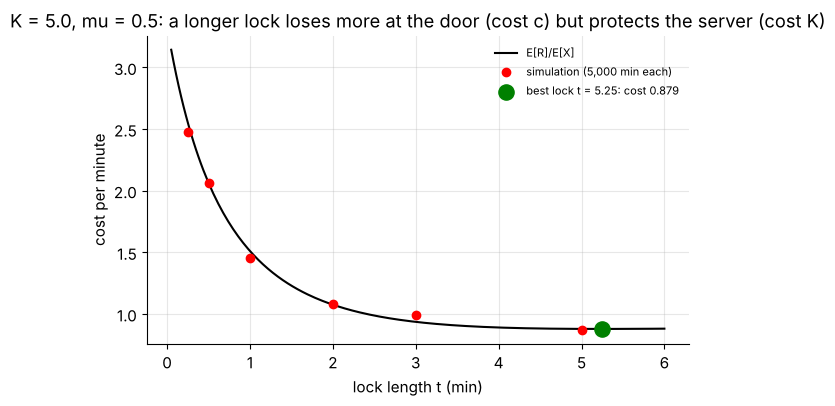

In [9]:
def door_demo(K=5.0, mu=0.5):
    """Cost per unit time as a function of the lock length t (lam = 1, c = 1): theory curve and simulation points."""
    lam, c = 1.0, 1.0
    tt = np.linspace(0.05, 6, 200)
    theory = (lam*tt*c + K*np.exp(-mu*tt)*lam/(lam+mu)) / (tt + 1/lam)
    pts = np.array([0.25, 0.5, 1, 2, 3, 5])
    sim = [simulate_door(lam, t_, mu, c, K, 5_000, rng) for t_ in pts]
    plt.figure(figsize=(7, 4)); plt.plot(tt, theory, "k", label="E[R]/E[X]"); plt.plot(pts, sim, "ro", label="simulation (5,000 min each)")
    i = theory.argmin(); plt.scatter([tt[i]], [theory[i]], s=120, c="g", zorder=3, label=f"best lock t = {tt[i]:.2f}: cost {theory[i]:.3f}")
    plt.xlabel("lock length t (min)"); plt.ylabel("cost per minute"); plt.legend(fontsize=8)
    plt.title(f"K = {K}, mu = {mu}: a longer lock loses more at the door (cost c) but protects the server (cost K)"); plt.show()

show(door_demo, K=FloatSlider(min=0.5, max=20, step=0.5, value=5) if HAS_W else 5.0,
     mu=FloatSlider(min=0.1, max=3, step=0.1, value=0.5) if HAS_W else 0.5)

**Think about it** — (i) Where does the derivation use that service times are
exponential? What breaks with deterministic service times of 2 minutes
(try it in `simulate_door` — the theory stays the same, the simulation does not). (ii) For $K\to0$ the best lock length is $t\to0$;
for large $K$ it is not. Interpret the optimal $t$ as a trade-off between the two
costs.

---
## Section C — Age, remaining time, and the inspection paradox *(slides pp. 35–40/54)*

> $A(t)=t-S_{N(t)}$, $Y(t)=S_{N(t)+1}-t$, $C(t)=A(t)+Y(t)$. Time averages:
> $\frac1t\int_0^tA(s)\,ds\to\frac{E[X^2]}{2E[X]}$, the same for $Y$, hence $\frac{E[X^2]}{E[X]}\ge E[X]$ for $C$.

### Model
Sample the three variables at uniformly random inspection times of one long
path (`age_residual_samples`). Two cases to compute by hand: uniform$(0,1)$ gaps
(time average of the age $=\tfrac13$) and the trains of slide p. 40/54 — headways
alternating 4 and 12 minutes (mean 8), a passenger arriving at a random time
waits $E[X^2]/(2E[X])$ on average, not $E[X]/2$.

In [10]:
avg_age_uniform = (1/3) / (2 * 0.5)                # E[X^2]/(2 E[X]) for uniform(0,1): E[X^2] = 1/3, E[X] = 1/2
EX2_trains = (4**2 + 12**2) / 2                      # headways 4 and 12 with equal frequency
train_wait = EX2_trains / (2 * 8)                    # mean wait of a random passenger (minutes)
print(f"uniform(0,1): time average of the age = {avg_age_uniform:.4f}   trains: mean wait = {train_wait:.2f} min (not E[X]/2 = 4)")

uniform(0,1): time average of the age = 0.3333   trains: mean wait = 5.00 min (not E[X]/2 = 4)


In [11]:
check("time average of the age, uniform(0,1)", avg_age_uniform, 1/3, tol=1e-6)
check("mean wait at the train station (min)",   train_wait, 5.0, tol=1e-6)

[OK ] time average of the age, uniform(0,1): got 0.333333   (reference 0.333333)
[OK ] mean wait at the train station (min): got 5   (reference 5)


True

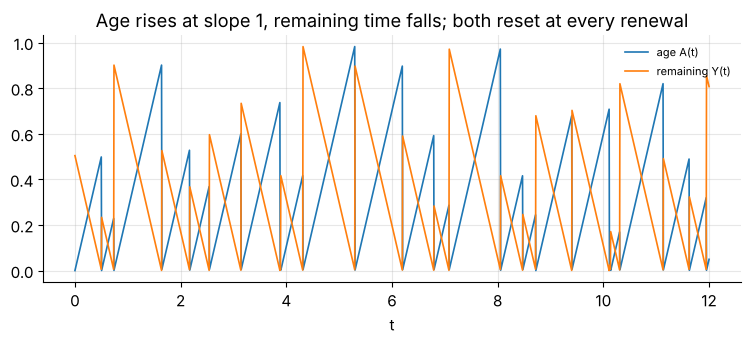

uniform(0,1): mean age 0.3354, mean remaining 0.3322  (theory 1/3 each);  mean spread 0.6676 (theory E[X^2]/E[X] = 2/3 > E[X] = 1/2)
trains: mean wait 4.982 min (theory 5), P(arriving in a 12-min gap) = 0.752 (theory 0.75)


In [12]:
# --- Simulate: the sawtooth, then the time averages at random inspection times ---------------------------
Uni = stats.uniform(0, 1)
S = simulate_renewal(sampler_from(Uni), 12, rng, overshoot=True)
fig, ax = plt.subplots(figsize=(9, 3.2)); plot_sawtooth(S, 12, ax); ax.set_title("Age rises at slope 1, remaining time falls; both reset at every renewal"); plt.show()

A, Y, C = age_residual_samples(sampler_from(Uni), T=20_000, rng=rng, n_times=50_000)
print(f"uniform(0,1): mean age {np.nanmean(A):.4f}, mean remaining {np.nanmean(Y):.4f}  (theory 1/3 each);  mean spread {np.nanmean(C):.4f} (theory E[X^2]/E[X] = 2/3 > E[X] = 1/2)")

# trains: headways 4, 12, 4, 12, ...; passengers arrive at uniform random times
bus = np.cumsum(np.tile([4.0, 12.0], 5000))                      # train epochs
tt = rng.uniform(0, bus[-1] - 20, 50_000)
_, wait, spread = age_residual(bus, tt)
print(f"trains: mean wait {wait.mean():.3f} min (theory 5), P(arriving in a 12-min gap) = {(spread > 8).mean():.3f} (theory 0.75)")

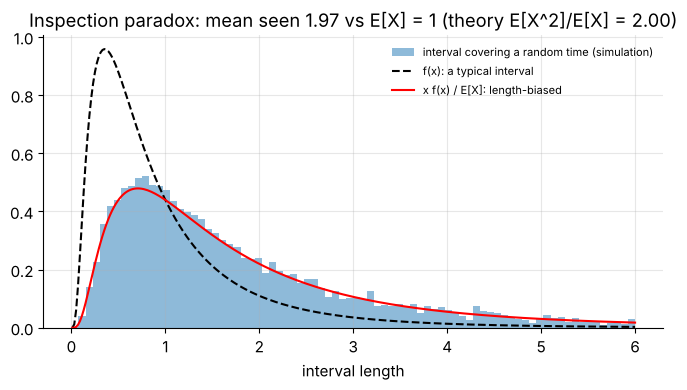

In [13]:
# --- Visualize the length bias: the interval covering a random time vs a typical interval ----------------
LN = stats.lognorm(s=math.sqrt(math.log(2)), scale=1/math.sqrt(2))      # lognormal, mean 1, cv 1
A, Y, C = age_residual_samples(sampler_from(LN), T=50_000, rng=rng, n_times=60_000)
xx = np.linspace(0.01, 6, 300)
plt.figure(figsize=(8, 3.8))
plt.hist(C[~np.isnan(C)], bins=80, range=(0, 6), density=True, alpha=.5, label="interval covering a random time (simulation)")
plt.plot(xx, LN.pdf(xx), "k--", label="f(x): a typical interval")
plt.plot(xx, length_biased_pdf(LN, xx), "r", label="x f(x) / E[X]: length-biased")
plt.xlabel("interval length"); plt.legend(fontsize=8)
plt.title(f"Inspection paradox: mean seen {np.nanmean(C):.2f} vs E[X] = 1 (theory E[X^2]/E[X] = {LN.moment(2):.2f})"); plt.show()

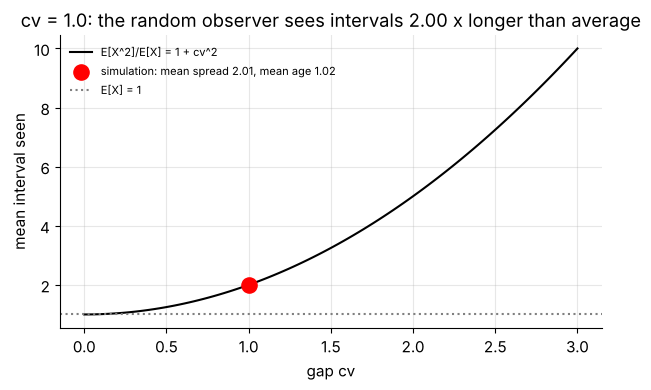

In [14]:
def spread_vs_cv(cv=1.0):
    """Mean spread seen by a random observer, lognormal gaps with mean 1 and the chosen cv: E[X^2]/E[X] = 1 + cv^2."""
    s2 = math.log(1 + cv**2)
    D = stats.lognorm(s=math.sqrt(s2), scale=math.exp(-s2/2))
    d = inspection_paradox_demo(D, T=20_000, rng=rng, n_times=20_000)
    cvs = np.linspace(0, 3, 100)
    plt.figure(figsize=(7, 3.8)); plt.plot(cvs, 1 + cvs**2, "k", label="E[X^2]/E[X] = 1 + cv^2")
    plt.scatter([cv], [d["spread_sim"]], s=120, c="r", zorder=3, label=f"simulation: mean spread {d['spread_sim']:.2f}, mean age {d['age_sim']:.2f}")
    plt.axhline(1, color="gray", ls=":", label="E[X] = 1"); plt.xlabel("gap cv"); plt.ylabel("mean interval seen"); plt.legend(fontsize=8)
    plt.title(f"cv = {cv}: the random observer sees intervals {d['spread_theory']:.2f} x longer than average"); plt.show()

show(spread_vs_cv, cv=FloatSlider(min=0, max=3, step=0.1, value=1.0) if HAS_W else 1.0)

**Think about it** — (i) For exponential gaps the mean spread is $2E[X]$: the
age and the remaining time are each $\exp(\lambda)$ — reconcile this with
memorylessness (slide p. 37/54). (ii) In the friendship paradox (slide p. 40/54)
what plays the role of $x f(x)/E[X]$? (iii) Design a sampling scheme that would
make the observed interval *unbiased* (hint: sample by renewal index, not by time).

---
## Problem 4 — Bus stop: number waiting and waiting time *(slide p. 50/54)*

> Consider a bus stop. Passengers arrive to the bus stop according to $PP(\lambda)$.
> Buses arrive according to a renewal process with inter-arrival distribution $F$.
> Passengers and buses arrive to the bus stop independently. (a) the average
> number of people at the bus stop in the long run. (b) the average amount of
> time that a passenger waits in the long run.

### Model
Buses are renewal epochs; reward per cycle = passenger-minutes
$\int_0^X N_p(s)\,ds$ with $E[\cdot]=\lambda E[X^2]/2$, so (a) $L=\lambda E[X^2]/(2E[X])$;
(b) a Poisson arrival lands at a random time and waits the remaining time:
$W=E[X^2]/(2E[X])$; and $L=\lambda W$ (slides pp. 51–52/54).
Numbers: $\lambda=2$ per minute, bus gaps uniform$(5,15)$ minutes.

In [15]:
lam = 2.0                                              # passengers per minute
EX, VarX = 10.0, 100/12                                # bus gaps uniform(5, 15): mean 10, variance 100/12
EX2 = VarX + EX**2
W = EX2 / (2 * EX)                                     # (b) mean wait (minutes)
L = lam * EX2 / (2 * EX)                               # (a) mean number waiting
print(f"E[X^2] = {EX2:.3f}   (a) L = {L:.3f} passengers   (b) W = {W:.3f} min   check L = lam W: {lam*W:.3f}")

E[X^2] = 108.333   (a) L = 10.833 passengers   (b) W = 5.417 min   check L = lam W: 10.833


In [16]:
check("E[X^2] of the bus gaps",     EX2, 100/12 + 100, tol=1e-6)
check("(a) L, mean number waiting",  L,   2*(100/12 + 100)/20, tol=1e-6)
check("(b) W, mean wait (minutes)",  W,   (100/12 + 100)/20,   tol=1e-6)

[OK ] E[X^2] of the bus gaps: got 108.333   (reference 108.333)
[OK ] (a) L, mean number waiting: got 10.8333   (reference 10.8333)
[OK ] (b) W, mean wait (minutes): got 5.41667   (reference 5.41667)


True

In [17]:
# --- Simulate the bus stop directly: buses U(5,15), passengers PP(2); measure L by random inspection, W per passenger ----
def simulate_bus_stop(gap_sampler, lam, T, rng, n_inspect=20_000):
    buses = simulate_renewal(gap_sampler, T, rng, overshoot=True)
    pax = poisson_process(lam, T, rng)
    pax = pax[pax < buses[-1]]
    nxt = buses[np.searchsorted(buses, pax, side="right")]            # the bus each passenger takes
    W_sim = (nxt - pax).mean()
    ts = rng.uniform(0, T, n_inspect)                                  # L: count passengers waiting at random times
    last_bus = np.where(np.searchsorted(buses, ts, side="right") > 0,
                        buses[np.maximum(np.searchsorted(buses, ts, side="right") - 1, 0)], 0.0)
    waiting = np.searchsorted(pax, ts, side="right") - np.searchsorted(pax, last_bus, side="right")
    return waiting.mean(), W_sim

uni = lambda r, n: r.uniform(5, 15, n)
L_sim, W_sim = simulate_bus_stop(uni, lam, 200_000, rng)
ref_W = (100/12 + 100)/20                                              # independent of your TODO
print(f"uniform(5,15) buses:  L sim {L_sim:.3f} (theory {2*ref_W:.3f})   W sim {W_sim:.3f} min (theory {ref_W:.3f})   L = lam W: {lam*W_sim:.3f}")

for name, g, ex2 in [("deterministic 10", lambda r, n: np.full(n, 10.0), 100.0),
                     ("exponential mean 10", lambda r, n: r.exponential(10, n), 200.0)]:
    L_s, W_s = simulate_bus_stop(g, lam, 200_000, rng)
    print(f"{name:>20} buses:  L sim {L_s:.2f} (theory {lam*ex2/20:.2f})   W sim {W_s:.2f} min (theory {ex2/20:.2f})")

uniform(5,15) buses:  L sim 10.733 (theory 10.833)   W sim 5.414 min (theory 5.417)   L = lam W: 10.829
    deterministic 10 buses:  L sim 9.95 (theory 10.00)   W sim 5.00 min (theory 5.00)
 exponential mean 10 buses:  L sim 19.77 (theory 20.00)   W sim 9.94 min (theory 10.00)


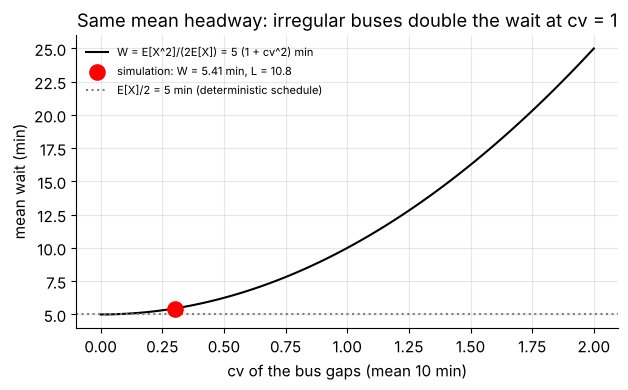

In [18]:
def bus_demo(cv=0.3):
    """Mean wait with lognormal bus gaps of mean 10 min and the chosen cv: W = 5 (1 + cv^2); L = 2 W."""
    s2 = math.log(1 + cv**2)
    g = lambda r, n: r.lognormal(math.log(10) - s2/2, math.sqrt(s2), n)
    L_s, W_s = simulate_bus_stop(g, 2.0, 100_000, rng)
    cvs = np.linspace(0, 2, 100)
    plt.figure(figsize=(7, 3.8)); plt.plot(cvs, 5*(1 + cvs**2), "k", label="W = E[X^2]/(2E[X]) = 5 (1 + cv^2) min")
    plt.scatter([cv], [W_s], s=120, c="r", zorder=3, label=f"simulation: W = {W_s:.2f} min, L = {L_s:.1f}")
    plt.axhline(5, color="gray", ls=":", label="E[X]/2 = 5 min (deterministic schedule)")
    plt.xlabel("cv of the bus gaps (mean 10 min)"); plt.ylabel("mean wait (min)"); plt.legend(fontsize=8)
    plt.title("Same mean headway: irregular buses double the wait at cv = 1"); plt.show()

show(bus_demo, cv=FloatSlider(min=0, max=2, step=0.1, value=0.3) if HAS_W else 0.3)

**Think about it** — (i) $L=\lambda W$ came out of two separate renewal reward
arguments; Ch.8 proves it in general (Little's law). What is the "reward" in
each argument? (ii) Why is a passenger's wait the *remaining* time of the bus
process rather than half a typical gap? Which property of Poisson arrivals is used?

---
## Section E — Regenerative processes and the alternating renewal process *(slides pp. 41–49/54)*

> Fraction of time in state $j$ $=E[$time in $j$ during a cycle$]/E[$cycle$]$;
> on/off system: fraction on $=E[Z]/(E[Z]+E[Y])$.

### Model
A machine with up times of mean 2 days and repair times of mean 1 day. With
exponential clocks it is the CTMC of CP8 §1 ($p_{\text{up}}=\lambda/(\lambda+\mu)$); the
regenerative view gives the same number from the cycle, and — unlike $pQ=0$ —
keeps giving it when the clocks are *not* exponential (HW3 Part C, explained).

In [19]:
m_up, m_repair = 2.0, 1.0
avail = m_up / (m_up + m_repair)                      # fraction of time on = E[Z]/(E[Z] + E[Y])
print(f"availability = {avail:.4f}   CTMC check (exp clocks): {machine_repair(1, 1, 1/m_up, 1/m_repair).stationary()[1]:.4f}")

availability = 0.6667   CTMC check (exp clocks): 0.6667


In [20]:
check("availability E[Z]/(E[Z]+E[Y])", avail, 2/3, tol=1e-6)

[OK ] availability E[Z]/(E[Z]+E[Y]): got 0.666667   (reference 0.666667)


True

          up times       repair times   on-fraction   (theory 2/3 = 0.6667)
       exponential        exponential   0.6647
       exponential          Erlang(4)   0.6675
     deterministic        exponential   0.6670
     deterministic          Erlang(4)   0.6668
  lognormal cv 1.5        exponential   0.6684
  lognormal cv 1.5          Erlang(4)   0.6700


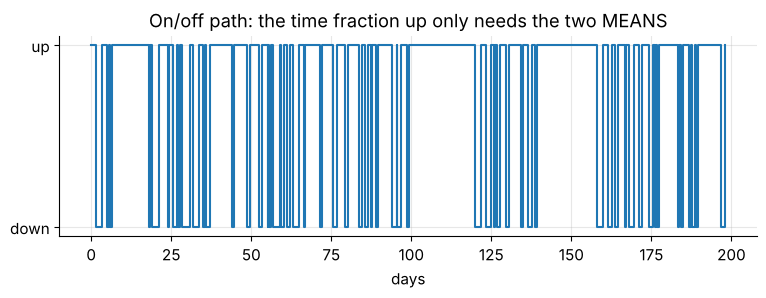

In [21]:
# --- Simulate the on/off process with several shapes of the same means -------------------------------------
shapes = {"exponential":  lambda mean: (lambda r, n: r.exponential(mean, n)),
          "deterministic": lambda mean: (lambda r, n: np.full(n, mean)),
          "Erlang(4)":     lambda mean: (lambda r, n: r.gamma(4, mean/4, n)),
          "lognormal cv 1.5": lambda mean: (lambda r, n: r.lognormal(math.log(mean) - 0.5*math.log(1 + 1.5**2), math.sqrt(math.log(1 + 1.5**2)), n))}
print(f"{'up times':>18} {'repair times':>18}   on-fraction   (theory 2/3 = {2/3:.4f})")
for up_name in ["exponential", "deterministic", "lognormal cv 1.5"]:
    for rep_name in ["exponential", "Erlang(4)"]:
        times, states, frac = alternating_renewal(shapes[up_name](m_up), shapes[rep_name](m_repair), 100_000, rng)
        print(f"{up_name:>18} {rep_name:>18}   {frac:.4f}")
# the regenerative formula seen on a path: cycles start at each repair completion
times, states, frac = alternating_renewal(shapes["lognormal cv 1.5"](m_up), shapes["Erlang(4)"](m_repair), 200, rng)
fig, ax = plt.subplots(figsize=(9, 2.6)); ax.step(times, states, where="post"); ax.set_yticks([0, 1]); ax.set_yticklabels(["down", "up"])
ax.set_xlabel("days"); ax.set_title("On/off path: the time fraction up only needs the two MEANS"); plt.show()

### Final-style · The fraction of time the age is at most $c$ *(slide p. 49/54)*

"On" at time $t$ if $A(t)\le c$: an alternating renewal process with on-time
$\min(X,c)$, so the fraction is $F_e(c)=\int_0^c(1-F(x))\,dx/E[X]$ — the
equilibrium distribution. For uniform$(0,1)$ gaps, $F_e(c)=2c-c^2$: the age is below
$\tfrac14$ for $43.75\%$ of the time although only $25\%$ of the intervals are that short.

In [22]:
Uni = stats.uniform(0, 1)
A, Y, C = age_residual_samples(sampler_from(Uni), T=20_000, rng=rng, n_times=50_000)
for c_ in [0.25, 0.5, 0.75]:
    print(f"c = {c_}: fraction of time with age <= c: sim {np.mean(A <= c_):.4f}   F_e(c) = 2c - c^2 = {2*c_ - c_**2:.4f}   (package: {equilibrium_cdf(Uni, c_):.4f});  F(c) = {c_:.2f}")
print("the remaining time has the same equilibrium law: P(Y <= 0.25) sim", np.mean(Y <= 0.25).round(4))

c = 0.25: fraction of time with age <= c: sim 0.4352   F_e(c) = 2c - c^2 = 0.4375   (package: 0.4375);  F(c) = 0.25
c = 0.5: fraction of time with age <= c: sim 0.7483   F_e(c) = 2c - c^2 = 0.7500   (package: 0.7500);  F(c) = 0.50
c = 0.75: fraction of time with age <= c: sim 0.9351   F_e(c) = 2c - c^2 = 0.9375   (package: 0.9375);  F(c) = 0.75
the remaining time has the same equilibrium law: P(Y <= 0.25) sim 0.4398


**Think about it** — (i) Prove the formula for a general $F$ in three lines
(2024 final-exam style; Companion Proof 8). (ii) For exponential gaps
$F_e=F$: which property is this? (iii) The mean of $F_e$ is $E[X^2]/(2E[X])$ —
derive it by integrating $1-F_e$.

---
## Problem 5 — Insurance premium rates: an alternating renewal process *(slide p. 53/54)*

> The rate a certain insurance company charges its policyholders (customers)
> alternates between $r_1$ and $r_0$. A new customer is initially charged at a rate
> $r_1$ per year. When a customer paying at rate $r_1$ has made no claims for $s$
> consecutive years, the rate becomes $r_0$ per year. The rate remains at $r_0$ until
> a claim is made, at which time it reverts to $r_1$. If a customer makes claims
> according to $PP(\lambda)$, (a) calculate the proportion of time that the customer
> pays at rates $r_1$ and $r_0$ in the long run; (b) obtain the long-run average
> amount paid per year.

### Model
Cycles from claim to claim, $X\sim\exp(\lambda)$: the customer pays $r_1$ for
$\min(s,X)$ and $r_0$ for the rest. $E[\min(s,X)]=(1-e^{-\lambda s})/\lambda$, so
$P_1=1-e^{-\lambda s}$, $P_0=e^{-\lambda s}$ and the average paid per year is
$r_0e^{-\lambda s}+r_1(1-e^{-\lambda s})$ (slide p. 54/54).
Numbers: $\lambda=0.2$ claims/year, $s=3$ years, $r_1=1000$, $r_0=600$.

In [23]:
lam, s, r1, r0 = 0.2, 3.0, 1000.0, 600.0
P1 = 1 - math.exp(-lam * s)                        # fraction of time at rate r1
P0 = math.exp(-lam * s)                            # fraction of time at rate r0
avg_paid = r0 * P0 + r1 * P1                       # long-run average paid per year
print(f"(a) P1 = {P1:.4f}, P0 = {P0:.4f}   (b) average paid per year = {avg_paid:.2f}")

(a) P1 = 0.4512, P0 = 0.5488   (b) average paid per year = 780.48


In [24]:
check("(a) P1, fraction at r1", P1, 1 - math.exp(-0.6), tol=1e-6)
check("(a) P0, fraction at r0", P0, math.exp(-0.6),     tol=1e-6)
check("(b) average paid per year", avg_paid, 600*math.exp(-0.6) + 1000*(1 - math.exp(-0.6)), tol=1e-4)

[OK ] (a) P1, fraction at r1: got 0.451188   (reference 0.451188)
[OK ] (a) P0, fraction at r0: got 0.548812   (reference 0.548812)
[OK ] (b) average paid per year: got 780.475   (reference 780.475)


True

P1 sim 0.4510 (theory 0.4512)   P0 sim 0.5490 (theory 0.5488)   average/year sim 780.41 (theory 780.48)


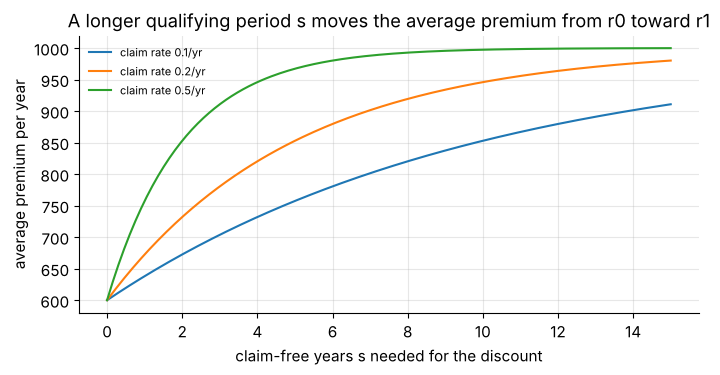

In [25]:
# --- Simulate the premium process from the claims alone --------------------------------------------------
T = 200_000                                                        # years of one customer's history
claims = poisson_process(lam, T, rng)
gaps = np.diff(np.concatenate([[0.0], claims]))                    # inter-claim intervals = cycles
time_r1 = np.minimum(gaps, s).sum(); time_r0 = np.maximum(gaps - s, 0).sum()
tot = time_r1 + time_r0
ref_P1 = 1 - math.exp(-lam*s)                                      # independent of your TODO
print(f"P1 sim {time_r1/tot:.4f} (theory {ref_P1:.4f})   P0 sim {time_r0/tot:.4f} (theory {1-ref_P1:.4f})   average/year sim {(r1*time_r1 + r0*time_r0)/tot:.2f} (theory {r0*(1-ref_P1) + r1*ref_P1:.2f})")

# the same numbers through the generic on/off simulator: on = paying r1 for min(X, s), off = the rest (dependent pair!)
plt.figure(figsize=(8, 3.6))
ss = np.linspace(0, 15, 200)
for lam_ in [0.1, 0.2, 0.5]:
    plt.plot(ss, r0*np.exp(-lam_*ss) + r1*(1 - np.exp(-lam_*ss)), label=f"claim rate {lam_}/yr")
plt.xlabel("claim-free years s needed for the discount"); plt.ylabel("average premium per year"); plt.legend(fontsize=8)
plt.title("A longer qualifying period s moves the average premium from r0 toward r1"); plt.show()

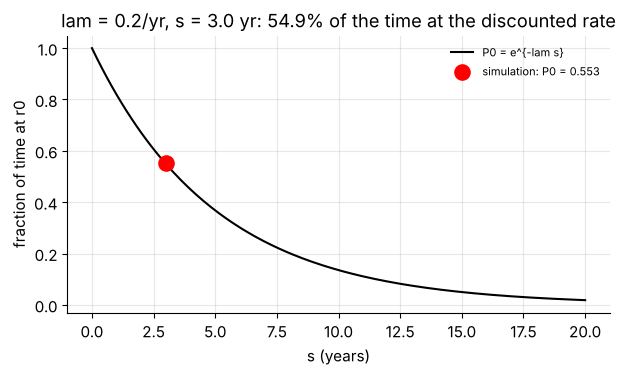

In [26]:
def premium_demo(s=3.0, lam=0.2):
    """Fraction of time at the discounted rate r0 = e^{-lam s}: theory vs a 20,000-year simulation."""
    cl = poisson_process(lam, 20_000, rng); g = np.diff(np.concatenate([[0.0], cl]))
    p0_sim = np.maximum(g - s, 0).sum() / g.sum()
    ss = np.linspace(0, 20, 200)
    plt.figure(figsize=(7, 3.6)); plt.plot(ss, np.exp(-lam*ss), "k", label="P0 = e^{-lam s}")
    plt.scatter([s], [p0_sim], s=120, c="r", zorder=3, label=f"simulation: P0 = {p0_sim:.3f}")
    plt.xlabel("s (years)"); plt.ylabel("fraction of time at r0"); plt.legend(fontsize=8)
    plt.title(f"lam = {lam}/yr, s = {s} yr: {100*math.exp(-lam*s):.1f}% of the time at the discounted rate"); plt.show()

show(premium_demo, s=FloatSlider(min=0, max=15, step=0.5, value=3) if HAS_W else 3.0,
     lam=FloatSlider(min=0.05, max=1, step=0.05, value=0.2) if HAS_W else 0.2)

**Think about it** — (i) Here the on-time $\min(s,X)$ and the off-time
$(X-s)^+$ of a cycle are *dependent*. Why does the alternating-renewal formula
not care? (ii) (a) is also "$P(\text{age of the claim process}\le s)$" — which
formula of Section E gives it directly? (iii) What changes if claims form a
renewal process with Erlang(2) gaps of the same rate?

---
## Wrap-up

| question | tool | answer |
|---|---|---|
| warm-up | ratio of means | $E[X^2]/E[X]=13/12$, not $E[R/X]=1$ |
| door (#3) | cycle $=t+\exp(\lambda)$, $R=C_1+C_2$ | $\dfrac{\lambda tc+Ke^{-\mu t}\lambda/(\lambda+\mu)}{t+1/\lambda}\approx1.51$/min |
| age / remaining / spread | renewal reward with $R=X^2/2$ | $E[X^2]/(2E[X])$ each; uniform$(0,1)$: $\tfrac13$; trains: 5 min |
| inspection paradox | length-biased density $xf(x)/E[X]$ | mean seen $=E[X^2]/E[X]=E[X](1+\mathrm{cv}^2)$ |
| bus stop (#4) | passenger-minutes per cycle; random-time wait | $L=\lambda E[X^2]/(2E[X])=10.8$, $W=5.42$ min, $L=\lambda W$ |
| availability | alternating renewal | $E[Z]/(E[Z]+E[Y])=\tfrac23$ for any shapes |
| age $\le c$ (final-style) | on-time $\min(X,c)$ | $F_e(c)=\int_0^c(1-F)/E[X]$; uniform: $2c-c^2$ |
| insurance (#5) | claim-to-claim cycles | $P_0=e^{-\lambda s}=0.549$, average $780.5$/yr |

**Next:** HW4 (Part C: how the gap *variance* sets the convergence speed of
$N(t)/t$, and the insensitivity of HW3 Part C explained by cycles), then Ch.8 —
queues, where Little's law $L=\lambda W$ returns in general.